In [1]:
#Importar las librerias
from pathlib import Path
import sys

# Carpeta raíz del proyecto
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import os
import pandas as pd
import tensorflow as tf
import random
import numpy as np
from modelos.AutoencoderModel import AutoencoderModel
import numpy as np
import warnings

warnings.filterwarnings('ignore')


# Fijar la semilla para los modelos neuronales
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
df_pandas = pd.read_csv("/data_simulada/preprocesado_Polars.csv") # Se importa el CSV

In [3]:
# ================================
# AUTOENCODER
# ================================

# 1. Definir etiquetas reales para evaluación
true_labels = df_pandas['empeoramiento'].values

# 2. Crear el modelo de autoencoder y escalar datos
autoencoder = AutoencoderModel(df_pandas, encoding_dim=4, learning_rate= 0.001)

# 3. Construir el modelo
autoencoder.build_model()

Columnas usadas para el autoencoder: ['aceleracion_x', 'aceleracion_y', 'aceleracion_z', 'magnitud_movimiento', 'actividad_estimada', 'spo2', 'frecuencia_cardiaca', 'pulsatility_index', 'senal_respiratoria', 'frecuencia_respiratoria', 'variabilidad_respiratoria', 'amplitud_instante', 'senal_sueno']


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4)              │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             

 Total params: 26,337 (102.88 KB)

 Trainable params: 25,433 (99.35 KB)

 Non-trainable params: 904 (3.53 KB)

None


In [ ]:
# 4. Entrenar el modelo
autoencoder.train(epochs=150, batch_size=256)

# Cargar el modelo para usar uno ya entrenado
# autoencoder.load_model("modelos/autoencoder_ela.keras")

Epoch 1/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0595 - val_loss: 0.0288
Epoch 2/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0255 - val_loss: 0.0210
Epoch 3/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0228 - val_loss: 0.0193
Epoch 4/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0214 - val_loss: 0.0185
Epoch 5/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0203 - val_loss: 0.0175
Epoch 6/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0194 - val_loss: 0.0170
Epoch 7/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0187 - val_loss: 0.0165
Epoch 8/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0181 - val_loss: 0.0161
Epoch 9/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0176 - val_loss: 0.0152
Epoch 10/150
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0171 - val_loss: 0.0150
Epoch 11/150


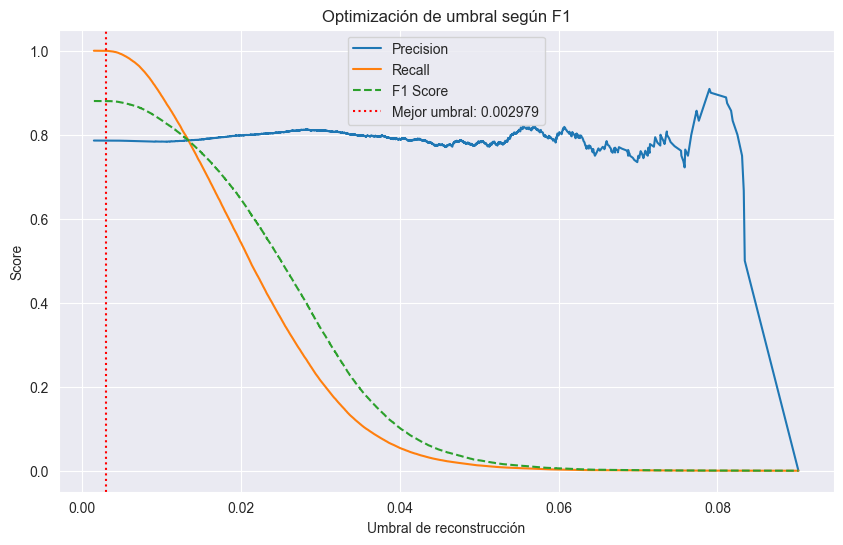

Mejor F1: 0.8803 con umbral: 0.002979
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 2s 767us/step
Métricas de evaluación:
  Precision: 0.7862
  Recall: 0.9998
  F1-score: 0.8803
  AUC: 0.5191


In [ ]:
# 7. Evaluar el modelo con métricas y curvas ROC/PR
metrics = autoencoder.evaluate(true_labels)

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 2s 766us/step
Umbral automático de anomalía: 0.035662


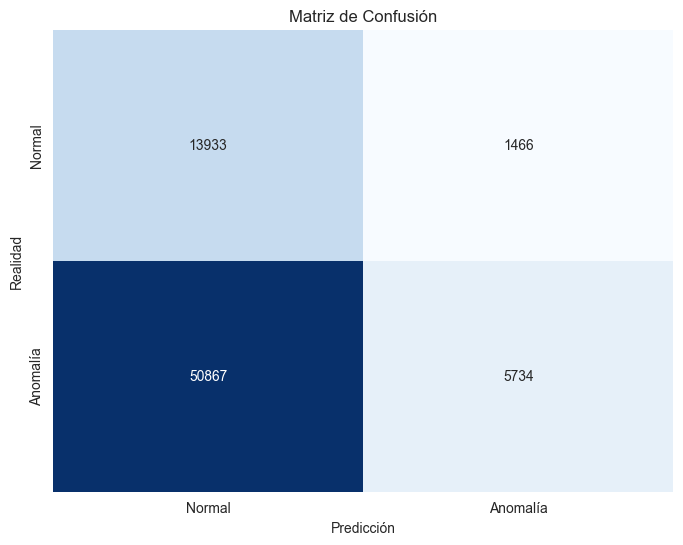

In [ ]:
# 8. Evaluar el modelo con la matriz de confusión
autoencoder.plot_confusion_matrix(true_labels)

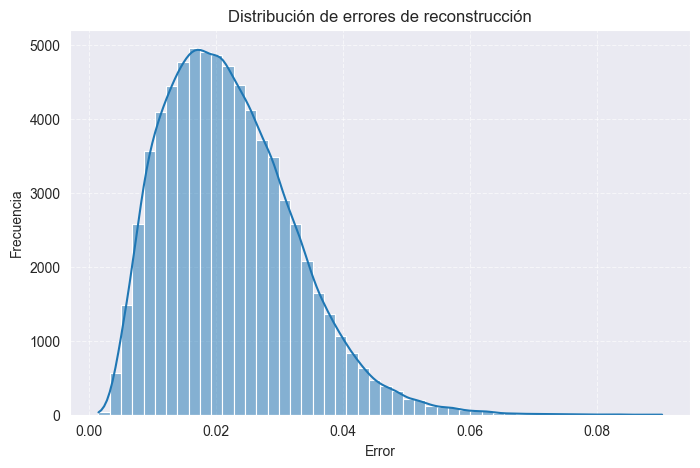

In [ ]:
# 9. Visualizar la distribución de errores
autoencoder.plot_error_distribution()

In [ ]:
# 10. Guardar el modelo entrenado
autoencoder.save_model("../modelos/autoencoder_ela.keras")

Modelo guardado en: modelos/autoencoder_ela.keras
